# PyBaMM tutorial

For more details and in-depth explanations, refer to the [PyBaMM docs](https://docs.pybamm.org/en/stable/index.html)

In [1]:
import pybamm

In [2]:
model = pybamm.lithium_ion.DFN()  # Doyle-Fuller-Newman model
sim = pybamm.Simulation(model)
sim.solve([0, 3600])
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

In [3]:
output_variables = ["Electrolyte concentration [mol.m-3]", "Voltage [V]"]
sim.plot(output_variables)

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

# Setting the parameter set

In [4]:
parameter_values = pybamm.ParameterValues("Chen2020")

In [5]:
parameter_values

{'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': np.float64(1.380649e-23),
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008 at 0x129d48220>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008 at 0x129d480e0>,
 'Electron charge [C]': np.float64(1.602176634e-19),
 'Faraday constant [C.mol-1]': np.float64(96485.33212331001),
 'Ideal gas constant [J.K-1.mol-1]': np.float64(8.31446261815324),
 'Initial SEI thickness [m]': 5e-09,
 'Initial concentration in electrolyte [mol.m-3]': 

In [6]:
model = pybamm.lithium_ion.DFN()

sim = pybamm.Simulation(model=model, parameter_values=parameter_values)
sim.solve([0, 3600])
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=3555.4443163107762, step=35.55444316310776),…

In [7]:
from params_lgm50 import get_parameter_values

model = pybamm.lithium_ion.DFN()
params = get_parameter_values()

sim = pybamm.Simulation(model=model, parameter_values=params)
soln = sim.solve([0, 3600])
sim.plot()

voltage = soln["Voltage [V]"].entries
time = soln["Time [s]"].entries

interactive(children=(FloatSlider(value=0.0, description='t', max=3552.2961733081215, step=35.52296173308122),…

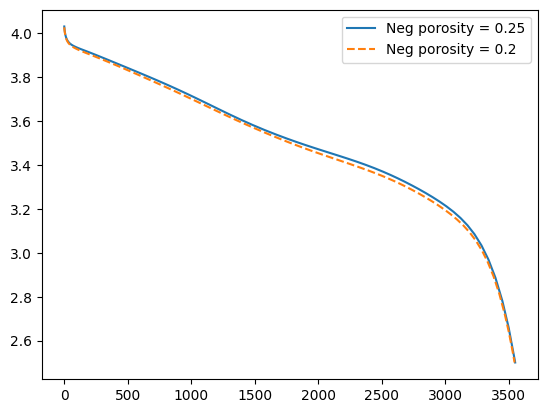

In [8]:
from params_lgm50 import get_parameter_values
import matplotlib.pyplot as plt

model = pybamm.lithium_ion.DFN()
params = get_parameter_values()

params.update({"Negative electrode porosity": 0.2}, check_already_exists=False)

sim = pybamm.Simulation(model=model, parameter_values=params)
soln = sim.solve([0, 3600])
# sim.plot()

plt.plot(time, voltage, label="Neg porosity = 0.25")
plt.plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="Neg porosity = 0.2", linestyle="--")
plt.legend()

# Setting up an experiment

## String based description

In [9]:
"Discharge at 1C for 0.5 hours",
"Discharge at C/20 for 0.5 hours",
"Charge at 0.5 C for 45 minutes",
"Discharge at 1 A for 90 seconds",
"Charge at 200mA for 45 minutes",
"Discharge at 1 W for 0.5 hours",
"Charge at 200 mW for 45 minutes",
"Rest for 10 minutes",
"Hold at 1 V for 20 seconds",
"Charge at 1 C until 4.1V",
"Hold at 4.1 V until 50 mA",
"Hold at 3V until C/50",

('Hold at 3V until C/50',)

In [10]:
experiment = pybamm.Experiment(
    [
        "Discharge at C/10 for 10 hours or until 3.3 V",
        "Rest for 1 hour",
        "Charge at 1 A until 4.1 V",
        "Hold at 4.1 V until 50 mA",
        "Rest for 1 hour",
    ])

In [11]:
model = pybamm.lithium_ion.DFN()
parameter_values = pybamm.ParameterValues("Chen2020")
sim = pybamm.Simulation(model, parameter_values=parameter_values, experiment=experiment)
sim.solve()

sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=17.046169761233333, step=0.17046169761233332…

# Current function

In [12]:
import numpy as np
def current_func(t):
    return 0.5 + 0.1 * np.sin(t/180)

model = pybamm.lithium_ion.DFN()
parameter_values = pybamm.ParameterValues("Chen2020")
parameter_values.update({"Current function [A]": current_func}, check_already_exists=False)

sim = pybamm.Simulation(model, parameter_values=parameter_values)
sim.solve([0, 3600])

sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

Text(0, 0.5, 'Power [W]')

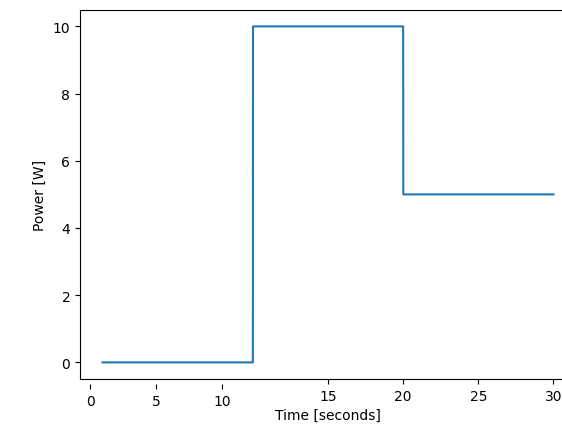

In [13]:
import matplotlib.pyplot as plt
power = np.array([0.0, 0.0, 10, 10, 5, 5])
time = np.array([0.0, 10.0, 10.01, 20.0, 20.01, 30.0])

plt.plot(time, power)
plt.xlabel("Time [seconds]")
plt.ylabel("Power [W]")


In [14]:
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})

power_interpolant = pybamm.Interpolant(time, power, pybamm.t)

parameter_values = pybamm.ParameterValues("Chen2020")
parameter_values.update({"Power function [W]": power_interpolant}, check_already_exists=False)

sim = pybamm.Simulation(model, parameter_values=parameter_values)
sim.solve([0, 30])

sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=30.0, step=0.3), Output()), _dom_classes=('w…

In [15]:
sim.plot(["Power [W]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=30.0, step=0.3), Output()), _dom_classes=('w…

# Solver options

Text(0, 0.5, 'Voltage [V]')

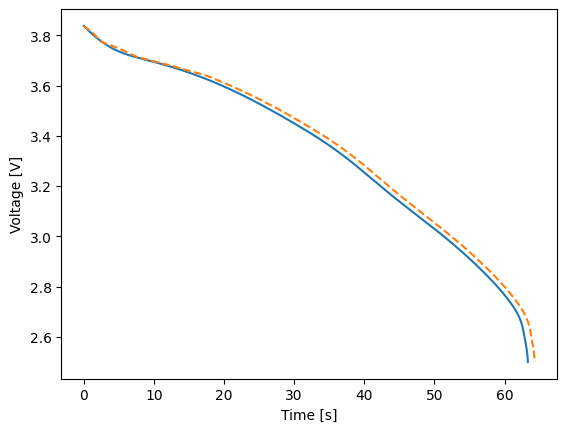

In [16]:
model = pybamm.lithium_ion.DFN()
parameter_values = pybamm.ParameterValues("Chen2020")

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=parameter_values, C_rate=5, solver=solver)
soln = sim.solve([0, 3600], initial_soc=1.0)

plt.plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries)

model = pybamm.lithium_ion.DFN()
parameter_values = pybamm.ParameterValues("Chen2020")

solver = pybamm.IDAKLUSolver(atol=1e-2, rtol=1e-2)
sim = pybamm.Simulation(model, parameter_values=parameter_values, C_rate=5, solver=solver)
soln = sim.solve([0, 3600], initial_soc=1.0)
plt.plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, linestyle="--")

plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")


# Breaking things down

In [17]:
model = pybamm.lithium_ion.DFN()

# Step 1: Parameter replacement
parameter_values = pybamm.ParameterValues("Chen2020")
parameter_values.process_model(model)
geometry = model.default_geometry
parameter_values.process_geometry(geometry)

# Step 2: Discretisation
mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)
disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
disc.process_model(model)

In [18]:
geometry

{'negative electrode': {'x_n': {'min': np.float64(0.0),
   'max': np.float64(8.52e-05)}},
 'separator': {'x_s': {'min': np.float64(8.52e-05),
   'max': np.float64(9.72e-05)}},
 'positive electrode': {'x_p': {'min': np.float64(9.72e-05),
   'max': np.float64(0.0001728)}},
 'negative particle': {'r_n': {'min': np.float64(0.0),
   'max': np.float64(5.86e-06)}},
 'positive particle': {'r_p': {'min': np.float64(0.0),
   'max': np.float64(5.22e-06)}},
 'current collector': {'z': {'position': np.float64(1.0)}}}

In [19]:
model.default_submesh_types

{'negative electrode': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'separator': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'positive electrode': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'negative particle': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'positive particle': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'negative primary particle': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'positive primary particle': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'negative secondary particle': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'positive secondary particle': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'negative particle size': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'positive particle size': pybamm.meshes.one_dimensional_submeshes.Uniform1DSubMesh,
 'negative primary particle size': pybamm.meshes.one_dimensional_submeshes.Unifo

In [20]:
model.default_var_pts

{'x_n': 20,
 'x_s': 20,
 'x_p': 20,
 'r_n': 20,
 'r_p': 20,
 'r_n_prim': 20,
 'r_p_prim': 20,
 'r_n_sec': 20,
 'r_p_sec': 20,
 'y': 10,
 'z': 10,
 'R_n': 30,
 'R_p': 30,
 'R_n_prim': 30,
 'R_p_prim': 30,
 'R_n_sec': 30,
 'R_p_sec': 30}

Text(0, 0.5, 'Voltage [V]')

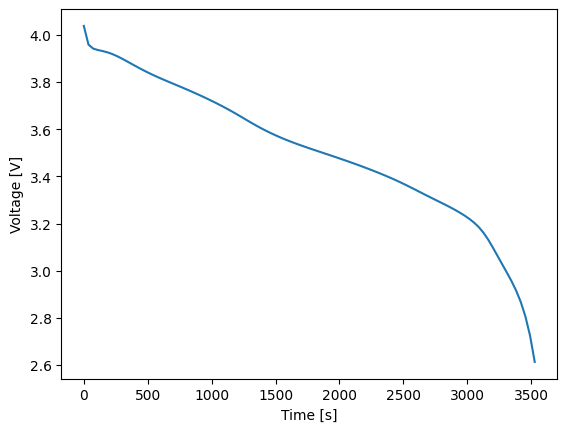

In [21]:
solver = pybamm.IDAKLUSolver()
solver.set_up(model)
solver._model_set_up.update(
    {model: {"initial conditions": model.concatenated_initial_conditions}}
)

# Step 4: Solver solve
solution = solver.solve(model, [0, 3600])

# Step 5: Post-processing
t_evals = np.linspace(0, 3600, 100)
voltage = solution["Terminal voltage [V]"](t_evals)

# Plot the results
import matplotlib.pyplot as plt

plt.plot(t_evals, voltage)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")

# Thermal modeling

$$
\rho_{eff} \frac{\partial T}{\partial t} = \bar{Q} - \frac{hA}{V}(T-T_{\infty})
$$

$$
Q = Q_{Ohm,k}+Q_{rxn,k}+Q_{rev,k}+Q_{cr}
$$


$$ Q_{Ohm,k} = -i_k \nabla \phi_k, \quad Q_{rxn,k} = a_k j_k \eta_k, \quad Q_{rev,k} = a_k j_k T_k \frac{\partial U}{\partial T} \bigg|_{T=T_{\infty}}, Q_{cr} = \frac{R_{cr}}{V_{cell}}i_k^2 $$

In [22]:
model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
parameter_values = pybamm.ParameterValues("Chen2020")

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=parameter_values, C_rate=1, solver=solver)
soln = sim.solve([0, 3600], initial_soc=1.0)

soln.plot(["Total heating [W]", "Cell temperature [K]"])


interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

# Degradation modeling

In [23]:
model = pybamm.lithium_ion.DFN(
    {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "true",
        "lithium plating": "partially reversible",
        "lithium plating porosity change": "true",  # alias for "SEI porosity change"
        "particle mechanics": ("swelling and cracking", "swelling only"),
        "SEI on cracks": "true",
        "loss of active material": "stress-driven",
    }
)

param = pybamm.ParameterValues("OKane2022")
var_pts = {
    "x_n": 10,  # negative electrode
    "x_s": 10,  # separator
    "x_p": 10,  # positive electrode
    "r_n": 30,  # negative particle
    "r_p": 30,  # positive particle
}

cycle_number = 10
exp = pybamm.Experiment(
    [
        "Hold at 4.2 V until C/100",
        "Rest for 4 hours",
        "Discharge at 0.1C until 2.5 V",  # initial capacity check
        "Charge at 0.3C until 4.2 V",
        "Hold at 4.2 V until C/100",
    ]
    + [
        (
            "Discharge at 1C until 2.5 V",  # ageing cycles
            "Charge at 0.3C until 4.2 V",
            "Hold at 4.2 V until C/100",
        )
    ]
    * cycle_number
    + ["Discharge at 0.1C until 2.5 V"],  # final capacity check
)
solver = pybamm.IDAKLUSolver(atol=1e-4, rtol=1e-4)
sim = pybamm.Simulation(
    model, parameter_values=param, experiment=exp, solver=solver, var_pts=var_pts
)
sol = sim.solve()

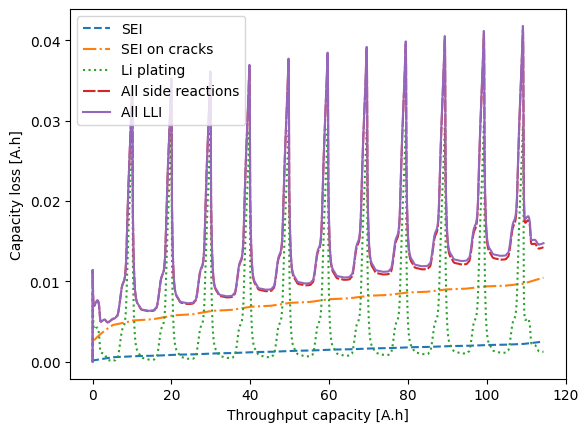

In [24]:
Qt = sol["Throughput capacity [A.h]"].entries
Q_SEI = sol["Loss of capacity to negative SEI [A.h]"].entries
Q_SEI_cr = sol["Loss of capacity to negative SEI on cracks [A.h]"].entries
Q_plating = sol["Loss of capacity to negative lithium plating [A.h]"].entries
Q_side = sol["Total capacity lost to side reactions [A.h]"].entries
Q_LLI = (
    sol["Total lithium lost [mol]"].entries * 96485.3 / 3600
)  # convert from mol to A.h
plt.figure()
plt.plot(Qt, Q_SEI, label="SEI", linestyle="dashed")
plt.plot(Qt, Q_SEI_cr, label="SEI on cracks", linestyle="dashdot")
plt.plot(Qt, Q_plating, label="Li plating", linestyle="dotted")
plt.plot(Qt, Q_side, label="All side reactions", linestyle=(0, (6, 1)))
plt.plot(Qt, Q_LLI, label="All LLI")
plt.xlabel("Throughput capacity [A.h]")
plt.ylabel("Capacity loss [A.h]")
plt.legend()
plt.show()